In [4]:
!pip install boto3
import pandas as pd
import boto3 # Corrected from boton3
import io
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import userdata

# Sacamos las claves para AWS
aws_access_key_id = userdata.get('AWS_ACCESS_KEY_ID')
aws_secret_access_key = userdata.get('AWS_SECRET_ACCESS_KEY')
aws_region = 'us-east-2'

s3_client = boto3.client( # Corrected from boton3.client
    's3', aws_access_key_id=aws_access_key_id, aws_secret_access_key=aws_secret_access_key, region_name=aws_region
)

print("Descargando la tabla del Banco desde S3...")
objeto_s3 = s3_client.get_object(Bucket='ia-bussiness2026', Key='UCI_Credit_Card.csv')
creditcard_df = pd.read_csv(io.BytesIO(objeto_s3['Body'].read()))
print("¡Archivo cargado exitosamente!")
creditcard_df.head()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.9 MB/s eta 0:00:00
Descargando la tabla del Banco desde S3...
¡Archivo cargado exitosamente!


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

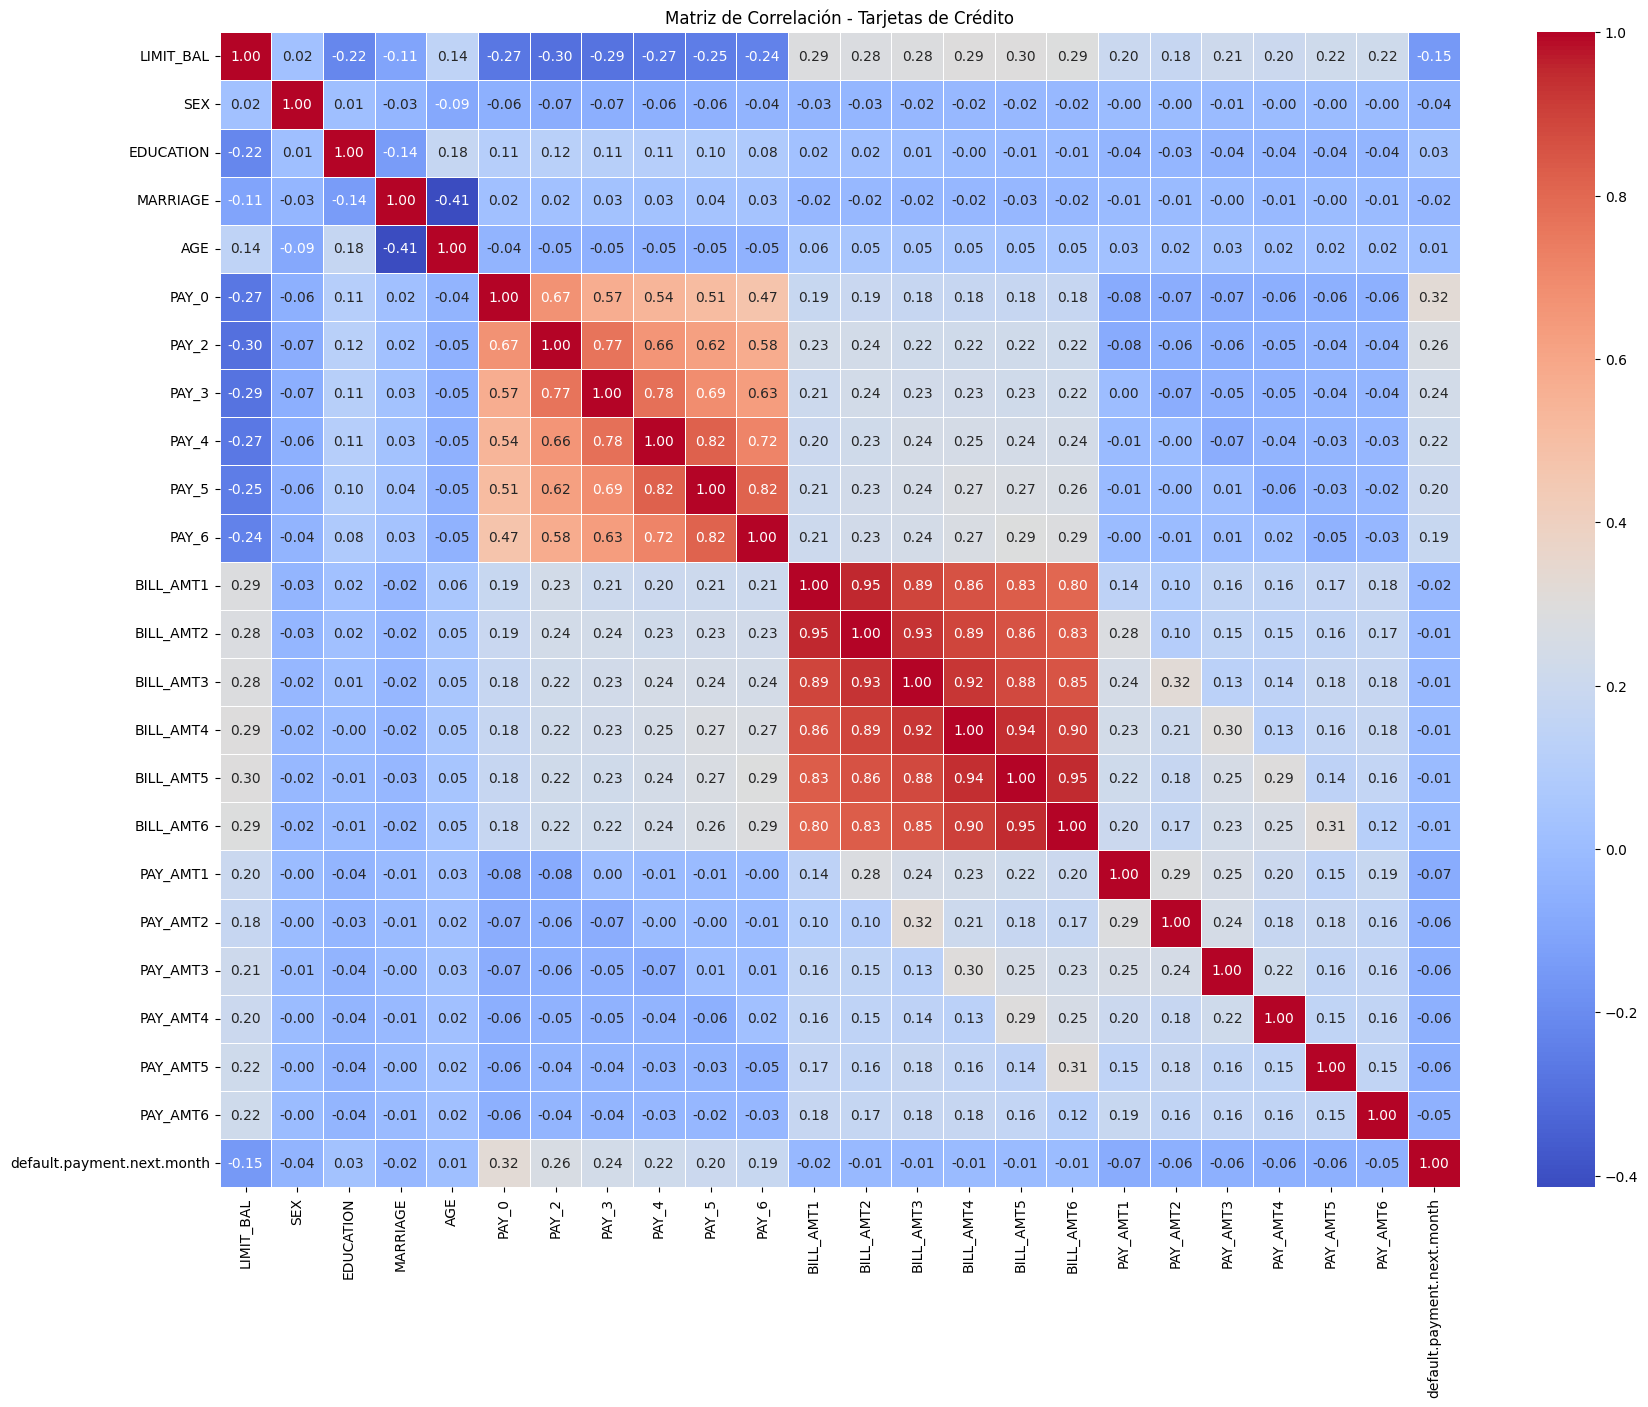

In [5]:
# Información del DataFrame
creditcard_df.info()

# Limpieza: Eliminar columna ID
creditcard_df.drop(['ID'], axis=1, inplace=True)

# Veamos el balance de la meta
cc_default_df = creditcard_df[creditcard_df['default.payment.next.month'] == 1]
cc_node_default_df = creditcard_df[creditcard_df['default.payment.next.month'] == 0]

print("Total: ", len(creditcard_df))
print("Incumplieron: ", len(cc_default_df))
print("Cumplieron: ", len(cc_node_default_df))

# Graficamos la Matriz que pediste
plt.figure(figsize=(20, 15))
sns.heatmap(creditcard_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación - Tarjetas de Crédito')
plt.show()


In [6]:
from sklearn.model_selection import train_test_split

target_col = 'default.payment.next.month'
cols = [target_col] + [col for col in creditcard_df.columns if col != target_col]
df_sagemaker = creditcard_df[cols]

# 2. Dividir los datos (Train: 70%, Validation: 20%, Test: 10%)
train_data, temp_data = train_test_split(df_sagemaker, test_size=0.3, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.33, random_state=42)

y_train = train_data.iloc[:, 0]
X_train = train_data.iloc[:, 1:]

y_val = val_data.iloc[:, 0]
X_val = val_data.iloc[:, 1:]

y_test = test_data.iloc[:, 0]
X_test = test_data.iloc[:, 1:]

print("Datos divididos y listos para entrenar ocultando la variable objetivo")


Datos divididos y listos para entrenar ocultando la variable objetivo


In [7]:
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore') # Apagamos advertencias rojas molestas
pd.Int64Index = pd.Index # Parche de Colab

# Tu misma configuración de XGBoost
modelo_final = xgb.XGBClassifier(
    max_depth=5,
    learning_rate=0.2,
    gamma=4,
    min_child_weight=6,
    subsample=0.8,
    objective='binary:logistic',
    eval_metric='auc',
    n_estimators=100,
    use_label_encoder=False
)

print("Entrenando el modelo en Colab...")
modelo_final.fit(
    X_train.values,
    y_train.values,
    eval_set=[(X_val.values, y_val.values)],
    verbose=False
)
print("¡Entrenamiento y validación completados!")


Entrenando el modelo en Colab... 🧠 (Costo: $0.00)
¡Entrenamiento y validación completados!


In [8]:
print("Preparando datos de prueba del cliente #1 (SIN la variable objetivo)...")
cliente_prueba = X_test.iloc[0:1].values
realidad_del_cliente = y_test.iloc[0]

print("Enviando petición a nuestro Modelo Central...")
# Usamos predict_proba para sacar la probabilidad decimal al igual que la API de AWS
probabilidades = modelo_final.predict_proba(cliente_prueba)
probabilidad = probabilidades[0][1] # Extrar la probablidad de Default (1)

print("\n--------------------------------------------------")
print(f"¡RESPUESTA RECIBIDA!")
print(f"Probabilidad de incumplimiento de pago: {probabilidad * 100:.2f}%")

if probabilidad > 0.5:
    print("Decisión del Modelo:  RECHAZAR CRÉDITO (Alto riesgo de impago)")
else:
    print("Decisión del Modelo:  APROBAR CRÉDITO (Bajo riesgo de impago)")

print("--------------------------------------------------")
print(f"VERIFICACIÓN: En la vida real, este cliente {'INCUMPLIÓ (Default)' if realidad_del_cliente == 1 else 'SÍ PAGÓ SU DEUDA'}")


Preparando datos de prueba del cliente #1 (SIN la variable objetivo)...
Enviando petición a nuestro Modelo Central...

--------------------------------------------------
¡RESPUESTA RECIBIDA!
Probabilidad de incumplimiento de pago: 4.33%
Decisión del Modelo: 👉 APROBAR CRÉDITO (Bajo riesgo de impago)
--------------------------------------------------
VERIFICACIÓN: En la vida real, este cliente SÍ PAGÓ SU DEUDA
